Framingham Heart Disease Study Analysis

The Framingham Heart Study was a multigenerational, long term study designed to identify and understand characteristics that impact one's risk of developing coronary heart disease (CHD) in the next 10 years. This project's objective is to build and train a classification model to predict a given person's risk of developing CHD.

TO DO LIST
Distribution of independent features (smoking, sex, BPMeds, etc)
How things stack up against the dependent variable
recognize that the set is imbalanced (tons more non CHD people than CHD)
Do some stuff with statistical tests like P value and hypothesis testing
Run some tests to see what columns can be removed
correlation heatmap
Somewhere you gotta use a two sample chi-squared test
end it there and start working on those missing values and imbalanced data stuff. Make different notebooks with different approaches that test different models that output their data to a results file.

In [3]:
# Loading the raw data and importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Investigating data integrity

In [4]:
# Size of the dataset
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 4240
Columns: 16


In [8]:
# Summary of null or missing values

df.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

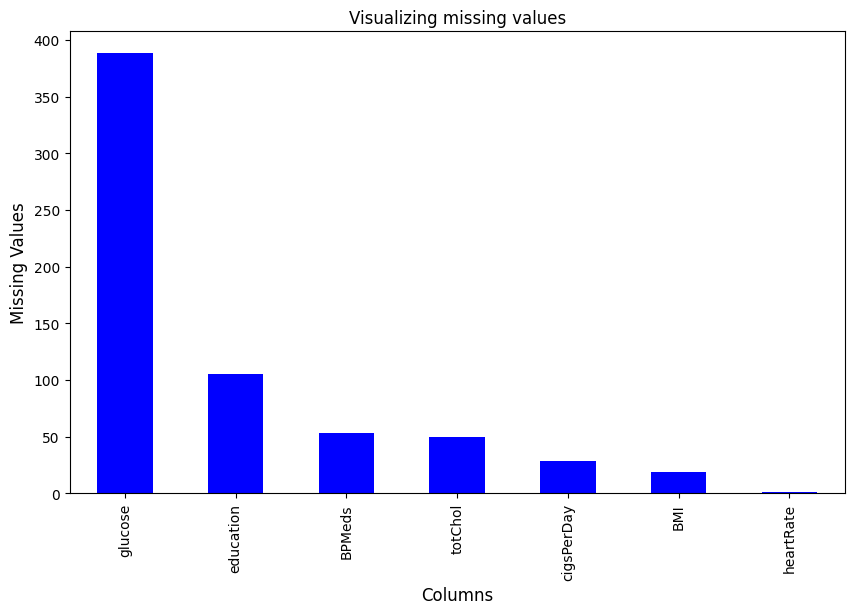

In [15]:
# Chart representation of columns with missing values

# Make a new dataframe of just the categories with a nonzero quantity of missing values
missing = df.isna().sum()
missing = missing[missing > 0]
missing = missing.sort_values(ascending=False) # Sort in descending order for ease of viewing

# Plot the bar chart
missing.plot(kind='bar', figsize=(10,6), color='blue')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Missing Values', fontsize=12)
plt.title('Visualizing missing values')
plt.show()


We can clearly see that there is quite a large quantity of missing values, especially within the glucose column.
# DETAIL HOW YOU PLAN TO DEAL WITH THIS MISSING DATA FOR THE MODELS

In [14]:
# Investigating duplicate data
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


Investigating the variables

In [16]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Variable summary

Target Variable (Nominal)
- 'TenYearCHD' : 10 year risk of developing CHD

Nominal Data:
- 'male' : The patient's sex
- 'currentSmoker' : Whether or not the patient smokes
- 'BPMeds' : Whether or not the patient is taking blood pressure medication
- 'prevalentStroke' : Whether or not the patient has had a stroke
- 'prevalentHyp' : Whether or not the patient has been hypertensive
- 'diabetes' : Whether or not the patient has diabetes

Ordinal Data
- 'education' : The patient's education level (no further detail provided)

Continuous Data
- 'age' : The patient's age
- 'cigsPerDay' : Average number of cigarettes smoked per day
- 'totChol' : Total cholesterol (mg/dL)
- 'sysBP' : Systolic Blood Pressure (mmHg)
- 'diaBP' : Diastolic Blood Pressure (mmHg)
- 'BMI' : Body Mass Index
- 'heartRate' : Heart rate
- 'glucose' : Glucose level (mg/dL)

<Axes: title={'center': 'Distribution of age in dataset'}, ylabel='Frequency'>

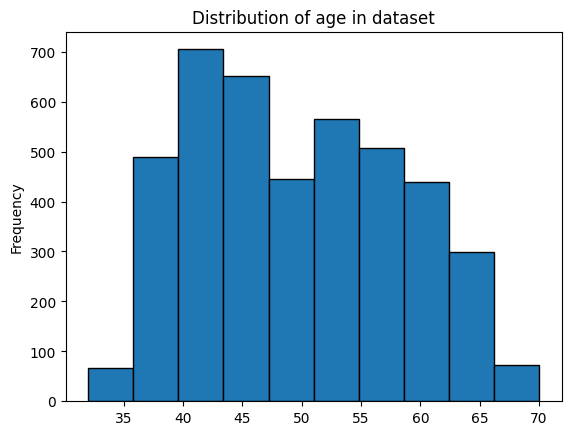

In [3]:
df['age'].plot(kind='hist', bins=10, title="Distribution of age in dataset", edgecolor='black')

<Axes: title={'center': 'Distribution of education level'}, ylabel='Frequency'>

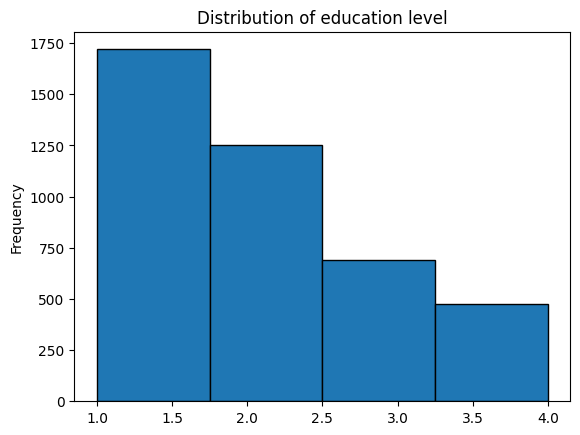

In [20]:
df['education'].plot(kind='hist', bins=4, title='Distribution of education level',edgecolor='black')
# Figure out how to get rid of unneeded numbers on x axis

<Axes: >

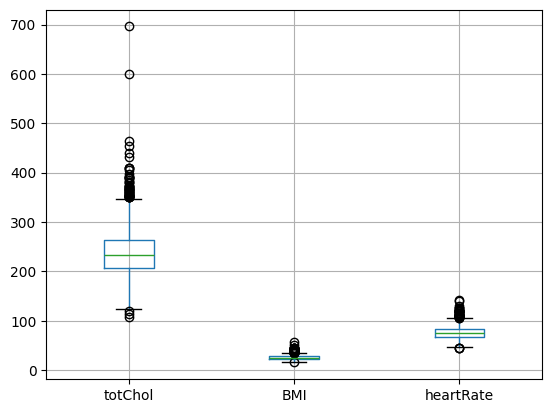

<Axes: >

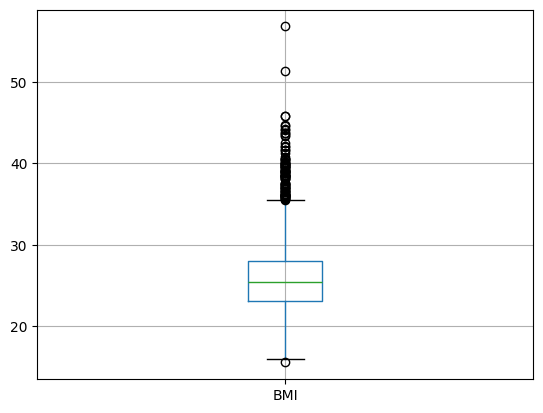

In [13]:
df.boxplot(column='BMI')

<Axes: title={'center': 'Genders'}, ylabel='Frequency'>

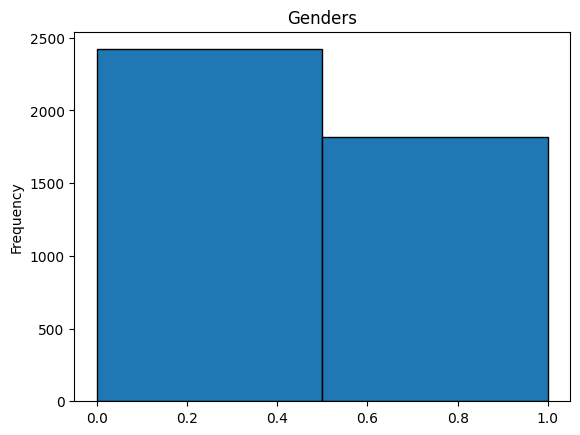

In [4]:
df['male'].plot(kind='hist', bins=2, title="Genders", edgecolor='black')
# Figure out how to label this correctly

<Axes: title={'center': 'Scatterplot of sysBP versus age'}, xlabel='age', ylabel='sysBP'>

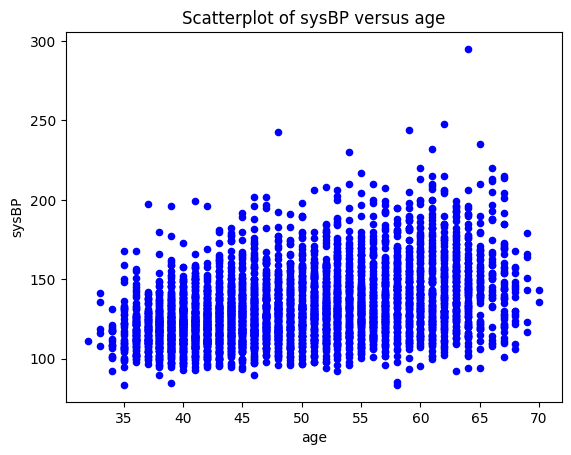

In [18]:
# Investigating relationship using a scatterplot to visualize outliers and correlation
df.plot(kind='scatter',x='age',y='sysBP',title='Scatterplot of sysBP versus age',alpha=1,color='blue')

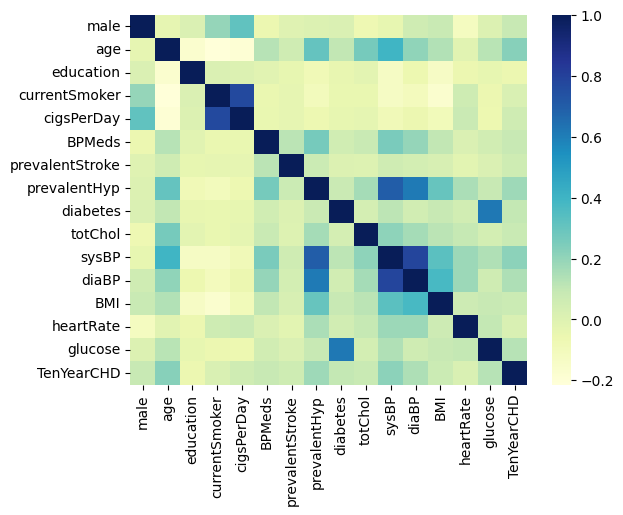

In [6]:
# Correlation heatmap
plot = sns.heatmap(df.corr(), cmap='YlGnBu', annot=False)

In [7]:
df.corr()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
male,1.000000,-0.029014,0.017415,0.197026,0.317143,-0.052504,-0.004550,0.005853,0.015693,-0.070413,-0.035879,0.058199,0.081871,-0.116932,0.005979,0.088374
age,-0.029014,1.000000,-0.166356,-0.213662,-0.192959,0.123052,0.057679,0.306799,0.101314,0.262554,0.394053,0.205586,0.136096,-0.012843,0.122356,0.225408
education,0.017415,-0.166356,1.000000,0.018528,0.008323,-0.010898,-0.035142,-0.081726,-0.038749,-0.023613,-0.129496,-0.061919,-0.137747,-0.054182,-0.035843,-0.054248
currentSmoker,0.197026,-0.213662,0.018528,1.000000,0.769774,-0.048927,-0.032980,-0.103710,-0.044285,-0.046488,-0.130281,-0.107933,-0.167857,0.062686,-0.056726,0.019448
cigsPerDay,0.317143,-0.192959,0.008323,0.769774,1.000000,-0.046155,-0.032711,-0.066645,-0.037089,-0.026479,-0.088797,-0.056715,-0.093293,0.075564,-0.058886,0.057755
BPMeds,-0.052504,0.123052,-0.010898,-0.048927,-0.046155,1.000000,0.117370,0.261067,0.052060,0.080623,0.254194,0.194122,0.100702,0.015230,0.051197,0.087519
prevalentStroke,-0.004550,0.057679,-0.035142,-0.032980,-0.032711,0.117370,1.000000,0.074791,0.006955,0.000105,0.057000,0.045153,0.025909,-0.017674,0.018440,0.061823
prevalentHyp,0.005853,0.306799,-0.081726,-0.103710,-0.066645,0.261067,0.074791,1.000000,0.077752,0.163632,0.696656,0.615840,0.301344,0.146815,0.086656,0.177458
diabetes,0.015693,0.101314,-0.038749,-0.044285,-0.037089,0.052060,0.006955,0.077752,1.000000,0.040348,0.111265,0.050260,0.087068,0.048986,0.617630,0.097344
totChol,-0.070413,0.262554,-0.023613,-0.046488,-0.026479,0.080623,0.000105,0.163632,0.040348,1.000000,0.208734,0.164698,0.115992,0.091127,0.046538,0.082369
